# Lab 4: Linear Regression & Its Variants
Predicting Continuous Values with Scikit-Learn and Real-World Data



---


**Course Code:** CS4082 Machine Learning

**Institution:** Effat University, Computer Science Department

**Student Name:** Ghala Alghamdi

**Student ID:** S23108212

**Instructor:** Dr. Naila Marir

**Date:** March 8, 2026


---

## 1 Lab Overview

In this lab, we shift to regression – predicting a
continuous number (e.g., house price, temperature, salary).

You will use a real-world housing dataset to learn Simple Linear Regression, Multiple Linear
Regression, Polynomial Regression, and Regularized Regression (Ridge, Lasso, ElasticNet) – all
through scikit-learn.

**Classification vs. Regression**

*Classification:* Output is a category. “Is this email spam or not?”

*Regression:* Output is a number. “What will this house sell for?”

### 1.1 What You Will Learn

- The difference between classification and regression

- Simple Linear Regression with one feature

- Multiple Linear Regression with many features

- Regression evaluation metrics: MSE, RMSE, MAE, R²

- Polynomial Regression for non-linear relationships

- Regularization: Ridge (L2), Lasso (L1), and ElasticNet

- Comparing multiple regression models on real data

### 1.2 Prerequisites

- Completion of Labs 2 and 3 (scikit-learn basics, preprocessing, pipelines)

- Basic understanding of linear equations (y= mx+ b)

- Google Colab account (recommended) or local Python 3.8+ installation

## 2 Part 1: The Idea Behind Linear Regression

Linear Regression finds the best straight line (or hyperplane) that relates input features to a
continuous output.

### 2.1 The Mathematical Model

**For a single feature, the model is simply:**

*ŷ= w1x+ w0*

where w1 is the slope (weight) and w0 is the intercept (bias).

**For multiple features, this generalizes to:**

*ŷ= w0 + w1x1 + w2x2 +···+ wnxn*

The goal of training is to find the weights w0,w1,...,wn that minimize the error between predictions ŷ and actual values y.

### 2.2 What Does “Best Fit” Mean?

Scikit-learn’s LinearRegression minimizes the Ordinary Least Squares (OLS) objective:

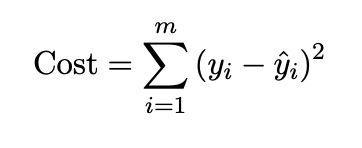

This is the sum of squared differences between each actual value and its prediction. The line
that makes this sum as small as possible is the “best fit.”

## 3 Part 2: Loading a Real Dataset – California Housing

We will use the California Housing dataset, a real dataset built into scikit-learn. It contains
information about housing districts in California collected from the 1990 U.S. census. The goal
is to predict the median house value for each district.

### 3.1 Dataset at a Glance

**Property:** Samples

 **Details:** 20,640 districts


---



**Property:** Features

**Details:** 8 numeric attributes


---



**Property:** Target

**Details:** Median house value (in $100,000s)



---



**Property:** Task

**Details:** Predict house value from district characteristics

### 3.2 Step 1: Load and Explore

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target   # target in $100,000s

print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())

print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

### 3.3 Step 2: Understand the Features

**Feature:** MedInc

**Description:** Median income of district

**Unit:** $10,000s


---

**Feature:** HouseAge

**Description:** Median house age

**Unit:** Years

---

**Feature:** AveRooms

**Description:** Average rooms per household  

**Unit:** Count

---

**Feature:** AveBedrms

**Description:** Average bedrooms per household  

**Unit:** Count

---

**Feature:** Population

**Description:** District population

**Unit:** People

---

**Feature:** AveOccup

**Description:** Average household members  

**Unit:** People

---

**Feature:** Latitude

**Description:** District latitude

**Unit:** Degrees

---

**Feature:** Longitude

**Description:** District longitude

**Unit:** Degrees

---

**Feature:** MedHouseVal

**Description:**  Median house value (target)

**Unit:** $100,000s

### 3.4 Step 3: Visualize Relationships

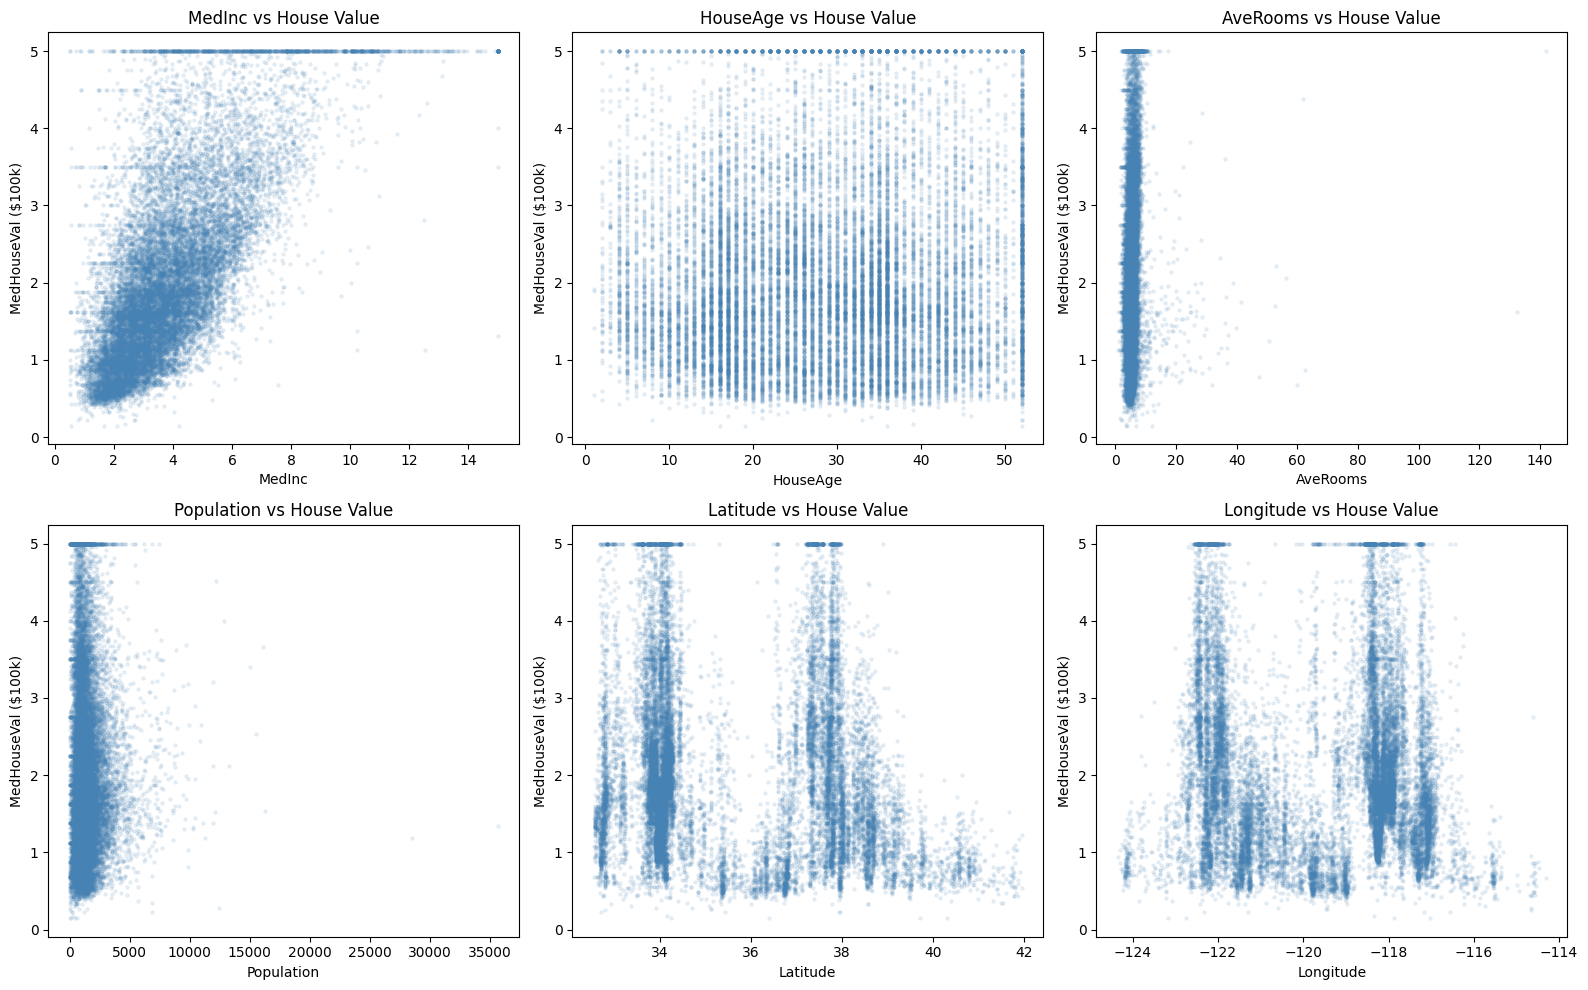

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

### Task 1: Explore the Dataset

In [3]:
#rank features by their correlation with the target using df.corr()[’MedHouseVal’].sort values()
df.corr()['MedHouseVal'].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


**Which feature has the strongest correlation?**

*The feature with the strongest positive correlation is MedInc (Median Income).*

*In this dataset, MedInc has a correlation of approximately **0.69** with MedHouseVal, which is much higher than the correlations of the other features.*

*This indicates that median income is the strongest predictor of house value among the available features.*

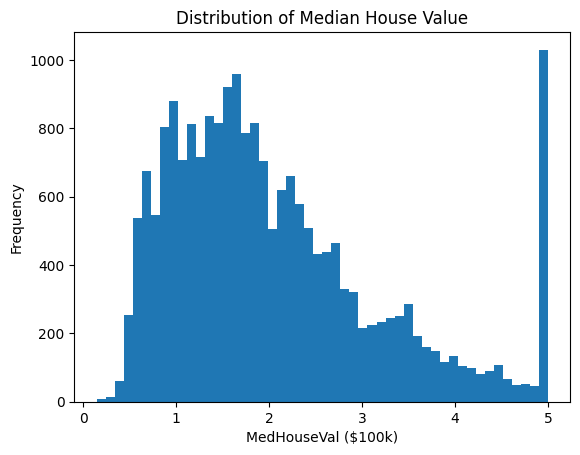

In [4]:
#Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],bins=50)

plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel('MedHouseVal ($100k)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

**Is the target normally distributed?**

*No, the distribution is right-skewed, not symmetric like a normal (bell-shaped) distribution.*

*Most house values are concentrated between about 0.5 and 3.0, and the frequency gradually decreases as values increase.*

**Do you notice a cap at 5.0 ($500,000)?**

*Yes, there is a very clear spike at 5.0, which indicates a maximum limit in the dataset.*

*Many house values stop at 5.0, meaning prices were capped at $500,000.*

In [5]:
#check how many samples are in the dataset
df.shape

(20640, 9)

**How many samples are in the dataset?**

*The dataset contains 20,640 samples*

**Is this enough for training a good model?**

*Yes, 20,640 samples is considered a large dataset for regression and is more than sufficient to train a reliable model.*

## 4 Part 3: Simple Linear Regression (One Feature)

Let’s start with the simplest case: predicting house value using only median income. This lets us visualize the regression line in 2D.

### 4.1 Step 1: Prepare Data

In [6]:
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16512
Testing samples: 4128


### 4.2 Step 2: Train and Visualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


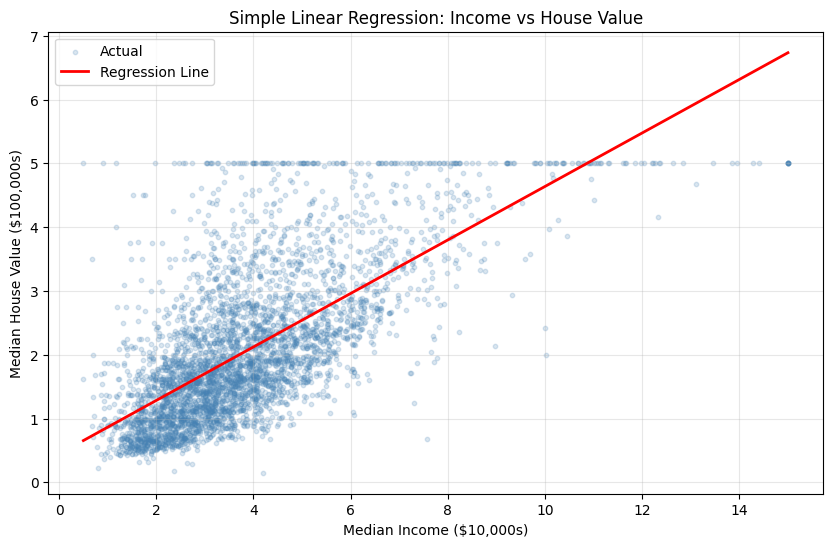

In [7]:
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')

print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc '
      f'+ ({model_simple.intercept_:.4f})')

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test,
            alpha=0.2, s=10,
            color='steelblue', label='Actual')

# Draw regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line,
         color='red', linewidth=2,
         label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 2: Interpret the Simple Model

**What are the slope and intercept? Write the equation.**

**Slope (w₁)** ≈ 0.4193

**Intercept (w₀)** ≈ 0.4446

*So the regression equation is:*

ŷ = 0.4193 × MedInc + 0.4446

*This means that for every increase of 1 unit in MedInc (which represents 10,000 dollars in median income), the predicted house value increases by approximately 0.4193 units (about $41,930).*

**What is the predicted house value for a district with income of 50,000 when (MedInc = 5.0)?**

*Since MedInc is in units of $10,000:*

*MedInc = 5.0 → $50,000 median income*

**Substitute into the equation:**

ŷ = 0.4193(5.0) + 0.4446

ŷ = 2.0965 + 0.4446

ŷ ≈ 2.5411

**So the predicted house value is:**

2.5411 ($100,000s)

**Convert to dollars:**

2.5411 × 100,000 ≈ $254,110


In [8]:
#verify with model simple.predict([[5.0]])
model_simple.predict([[5.0]])

array([2.54128976])

In [9]:
#try Using HouseAge Instead of MedInc
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_age = df[['HouseAge']].values

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)

y_pred_age = model_age.predict(X_test_age)

print("R²:", r2_score(y_test_age, y_pred_age))

R²: 0.012551235533311389


**Is it better or worse? Why?**

*The model using HouseAge is worse. It achieved an R² of 0.0126, meaning it explains only about 1.3% of the variance in house prices.*

*HouseAge has a weak correlation with house value, so it is not a strong predictor compared to median income.*

## 5 Part 4: Evaluating Regression Models

In classification, we used accuracy. For regression, we need different metrics since our predictions are continuous numbers, not categories.

### 5.1 The Four Key Metrics

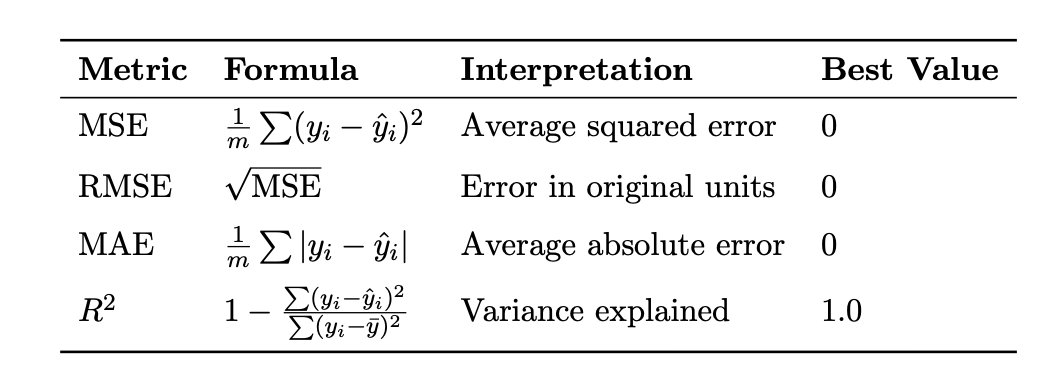

### 5.2 Step 1: Evaluate the Simple Model

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE: {mae:.4f} (error in $100,000s)')
print(f'R^2: {r2:.4f} ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


### 5.3 Step 2: Visualize Predictions vs. Actual

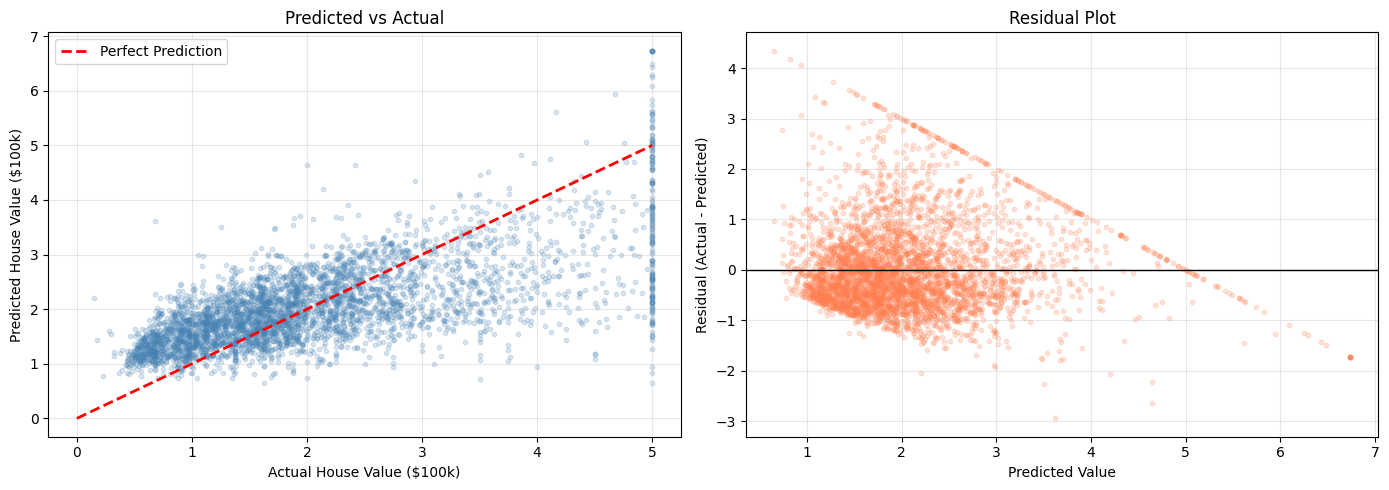

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple,
                alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2,
             label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals,
                alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3: Understand the Metrics

**Convert RMSE to actual dollars. If RMSE ≈0.74, what is the average prediction error in dollars?**

*If RMSE ≈ 0.74*

*The unit is $100,000s*

**0.74×100,000=74,000**

*The average prediction error is approximately $74,000*

**Look at the “Predicted vs Actual” plot. Where does the model struggle most – at low values, high values, or both?**

*The model struggles most at high house values.*

*In the plot, predictions for lower-priced houses are closer to the diagonal line, showing better accuracy. However, for expensive houses, many points fall below the line, meaning the model underpredicts high prices.*

*This happens partly because the dataset has a price cap at 5.0, which makes it harder for the model to learn patterns for very expensive homes.*

**What does the R² value tell you?**

*The R² value shows how much of the variation in house prices the model explains.*

*An R² of 0.4589 means the model explains about 46% of the variation using only median income.*

*This shows a moderate relationship, but more features are needed for better predictions.*

**Is a single feature enough to predict house prices well?**

*A single feature is not enough to predict house prices well.*

*Median income explains about 45.9% of the variation, but more than half remains unexplained.*

*House prices depend on multiple factors, so adding more features improves accuracy.*

## 6 Part 5: Multiple Linear Regression (All Features)

A single feature captures only part of the story. Let’s use all 8 features and see how much the
model improves.

### 6.1 Step 1: Train with All Features

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

print(f'\nImprovement over simple model:')
print(f'R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


### 6.2 Step 2: Feature Importance – Which Features Matter Most?

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


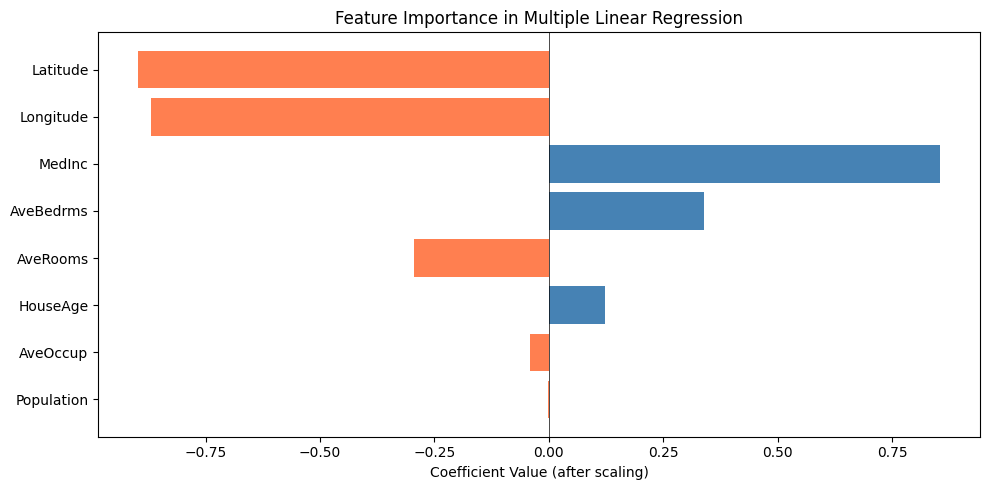

In [13]:
# Extract the learned coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral'
          for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Task 4: Analyze Multiple Regression

**List the top 3 most important features and the bottom 3.**

*These have the largest absolute coefficients, meaning they influence house value the most:*


1. Latitude

2. Longitude

3. MedInc

*These have very small coefficients, meaning they contribute very little to the prediction:*

1. Population

2. AveOccup

3. HouseAge



**Does this make intuitive sense?**

*Yes, the results make intuitive sense.*

- Median Income (MedInc) is one of the most important features, since higher-income neighborhoods typically have higher property values.

- Location (Latitude and Longitude) strongly influences house prices in California because properties near coastal and urban areas tend to be significantly more expensive than inland regions.

- In contrast, Population and Average Occupancy have much smaller coefficients, which is reasonable because they are less directly related to individual house prices compared to income and location.

**Why does Latitude have a negative coefficient? What does this mean geographically for California?**

*Latitude has a negative coefficient, meaning that as latitude increases (moving north in California), predicted house prices decrease.*

*Geographically, this suggests that southern California areas tend to have higher house prices compared to northern regions. This aligns with the fact that many high-demand coastal and southern areas are more expensive.*

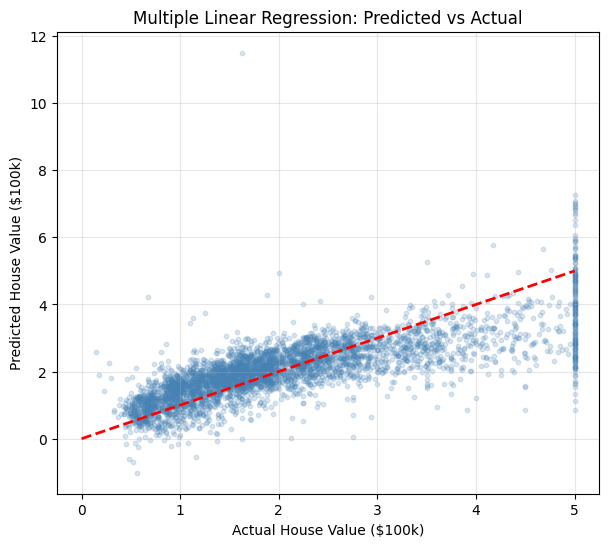

In [14]:
#create the “Predicted vs Actual” plot for the multiple regression model
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_multi,
            alpha=0.2, s=10, color='steelblue')

# Perfect prediction line
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)

plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple Linear Regression: Predicted vs Actual')
plt.grid(True, alpha=0.3)

plt.show()

**Compare it visually with the simple model. Is it closer to the diagonal?**

*The multiple regression plot is significantly closer to the diagonal line compared to the simple model. This indicates better prediction accuracy.*

*Using all features improves the model because house prices depend on multiple factors, not just income.*

## 7 Part 6: Polynomial Regression

Some relationships between features and target are not linear – they curve. Polynomial Regres-
sion handles this by creating new features that are powers of the originals (e.g., x2, x3), then fitting a linear model on the expanded feature set.

### 7.1 The Key Idea

For a single feature x, Polynomial Regression of degree 2 transforms:

**ŷ = w0 + w1x ---> ŷ = w0 + w1x+ w2x²**

The model is still linear in the weights (it just finds w0,w1,w2), but the relationship with x is now a curve.

### 7.2 Step 1: Polynomial on a Single Feature

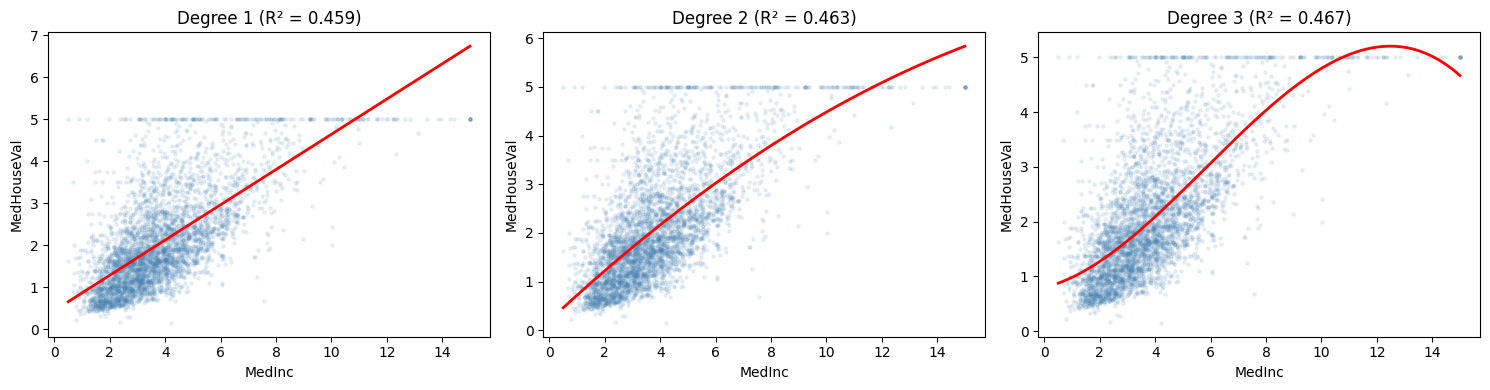

Polynomial Degree Comparison (MedInc only):
Degree 1: R² = 0.4589, RMSE = 0.8421
Degree 2: R² = 0.4633, RMSE = 0.8386
Degree 3: R² = 0.4671, RMSE = 0.8356


In [15]:
from sklearn.preprocessing import PolynomialFeatures

# Use only MedInc
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R² = {r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

# Print comparison
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"Degree {deg}: R² = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")

### 7.3 Step 2: Polynomial on All Features

In [16]:
from sklearn.preprocessing import StandardScaler

# Use all features with degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)

y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R^2: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')

# How many features now?
poly_features = pipe_poly_all.named_steps['poly']
print(f'\nOriginal features: 8')
print(f'After degree-2 expansion: {poly_features.n_output_features_}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


### Task 5: Explore Polynomial Regression

**Look at the three plots for degrees 1, 2, and 3. Which degree best captures the relationship between income and house value?**

*Degree 3 performs slightly best because it has the highest R² and lowest RMSE.*

*However, the improvement over Degree 2 is very small. Degree 2 already captures the curve well, so it is a good balance between accuracy and simplicity.*

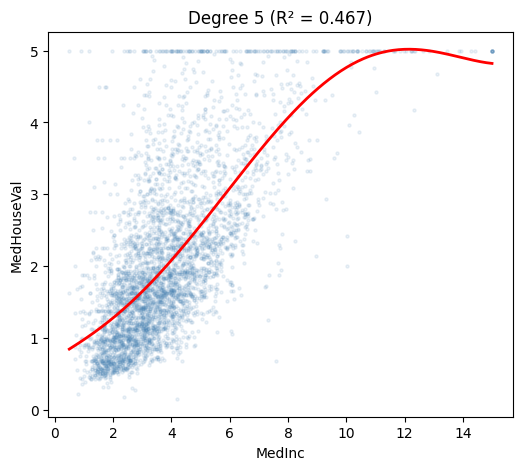

Degree 5 (MedInc only):
R² = 0.4668
RMSE = 0.8359


In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Use only MedInc
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Degree 5 only
pipe_poly_5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_5.fit(X_train_s, y_train)
y_pred_5 = pipe_poly_5.predict(X_test_s)

r2_5 = r2_score(y_test, y_pred_5)
rmse_5 = np.sqrt(mean_squared_error(y_test, y_pred_5))

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
y_plot = pipe_poly_5.predict(x_plot)
plt.plot(x_plot, y_plot, color='red', linewidth=2)

plt.title(f'Degree 5 (R² = {r2_5:.3f})')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.show()

print("Degree 5 (MedInc only):")
print(f"R² = {r2_5:.4f}")
print(f"RMSE = {rmse_5:.4f}")

**Does R² keep improving, or does it start to behave strangely at the edges?**

*R² increases slightly from degree 1 to degree 3, but it does not improve meaningfully at degree 5.*

*At higher degrees, the curve begins to bend unnaturally at the edges (very low and very high income values). This indicates overfitting, where the model becomes too complex and starts fitting noise instead of the true underlying relationship.*

*Degree 1 may slightly underfit the data, while degree 5 begins to overfit.*

In [18]:
#check how many features degree 3 create from 8 original features using
PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_train).shape

(16512, 164)

**How many features does degree 3 create from 8 original features?**

*Degree 3 expands the 8 original features into 164 features.*

## 8 Part 7: Regularized Regression – Ridge, Lasso, and Elastic-Net

When models have many features (especially after polynomial expansion), they can overfit.

Regularization adds a penalty to the cost function that discourages large weights, keeping
the model simpler and more generalizable.

### 8.1 The Three Variants

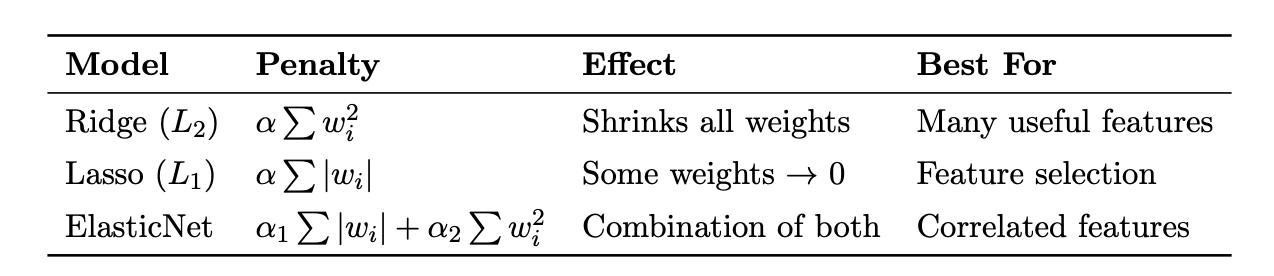

The parameter α controls the regularization strength: α= 0 gives standard Linear Regression;
larger α values mean stronger regularization (simpler model).

### 8.2 Step 1: Train All Three Variants

In [19]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Define models with pipelines
models = {
'LinearRegression': Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
]),
'Ridge (alpha=1.0)': Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
]),
'Lasso (alpha=0.01)': Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.01, random_state=42))
]),
'ElasticNet (alpha=0.01)': Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(alpha=0.01, l1_ratio=0.5,
                         random_state=42))
]),
}

# Train and evaluate each model
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}')
print('-' * 56)

results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {
        'RMSE': rmse_val,
        'MAE': mae_val,
        'R2': r2_val
    }

    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


### 8.3 Step 2: Compare Coefficients

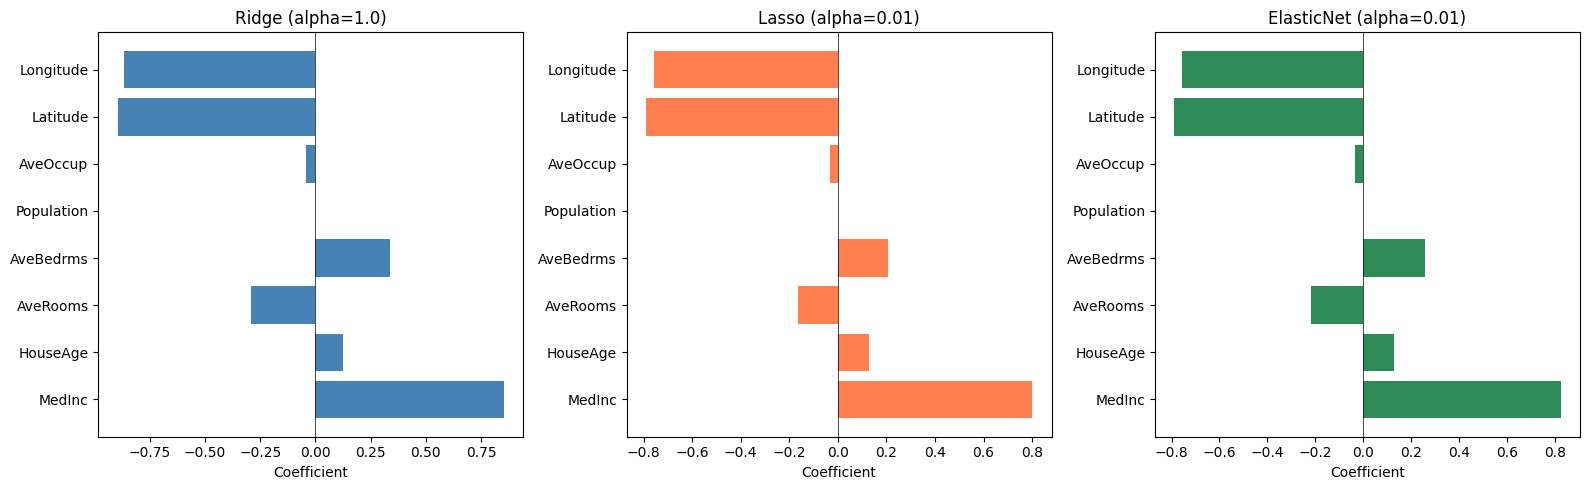


Lasso coefficients:
 MedInc      :   0.8010
 HouseAge    :   0.1271
 AveRooms    :  -0.1628
 AveBedrms   :   0.2062
 Population  :  -0.0000 <-- REMOVED 
 AveOccup    :  -0.0306
 Latitude    :  -0.7901
 Longitude   :  -0.7557


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = ['Ridge (alpha=1.0)',
               'Lasso (alpha=0.01)',
               'ElasticNet (alpha=0.01)']

colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# Check which features Lasso set to zero
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_

print('\nLasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED '
    print(f' {feat:12s}: {coef:>8.4f}{status}')

### Task 6: Explore Regularization

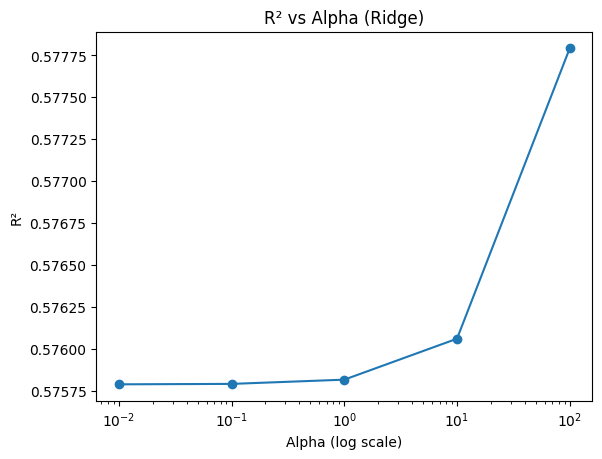



[(0.01, 0.5757879873121596), (0.1, 0.5757905180002312), (1.0, 0.575815742891368), (10.0, 0.5760599032848368), (100.0, 0.5777912763033602)]


In [21]:
#try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0.
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for a in alphas:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])

    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))

# Plot
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('R² vs Alpha (Ridge)')
plt.show()

print("\n")
print(list(zip(alphas, r2_scores)))

**What happens with very large α?**

*As α increases, the model applies stronger regularization, shrinking the coefficients.*

*For moderate α values, performance remains stable or may improve slightly, as seen in the plot.*

*However, if α becomes extremely large, the model can underfit the data because the coefficients are forced too close to zero, which would eventually reduce R².*

In [22]:
#try alpha=0.1 for Lasso
lasso_pipe_01 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, random_state=42))
])

lasso_pipe_01.fit(X_train, y_train)
lasso_coefs_01 = lasso_pipe_01.named_steps['model'].coef_

removed = [feat for feat, c in zip(housing.feature_names, lasso_coefs_01) if abs(c) < 1e-6]

print("Lasso (alpha=0.1) removed features:", removed)
print("Number removed:", len(removed))

Lasso (alpha=0.1) removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Number removed: 5


**How many features are removed (coefficient = 0)? Which ones?**

*With α = 0.1, Lasso removed 5 features by setting their coefficients to zero: AveRooms, AveBedrms, Population, AveOccup, and Longitude.*

*This demonstrates Lasso’s ability to perform automatic feature selection by eliminating less important predictors.*

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


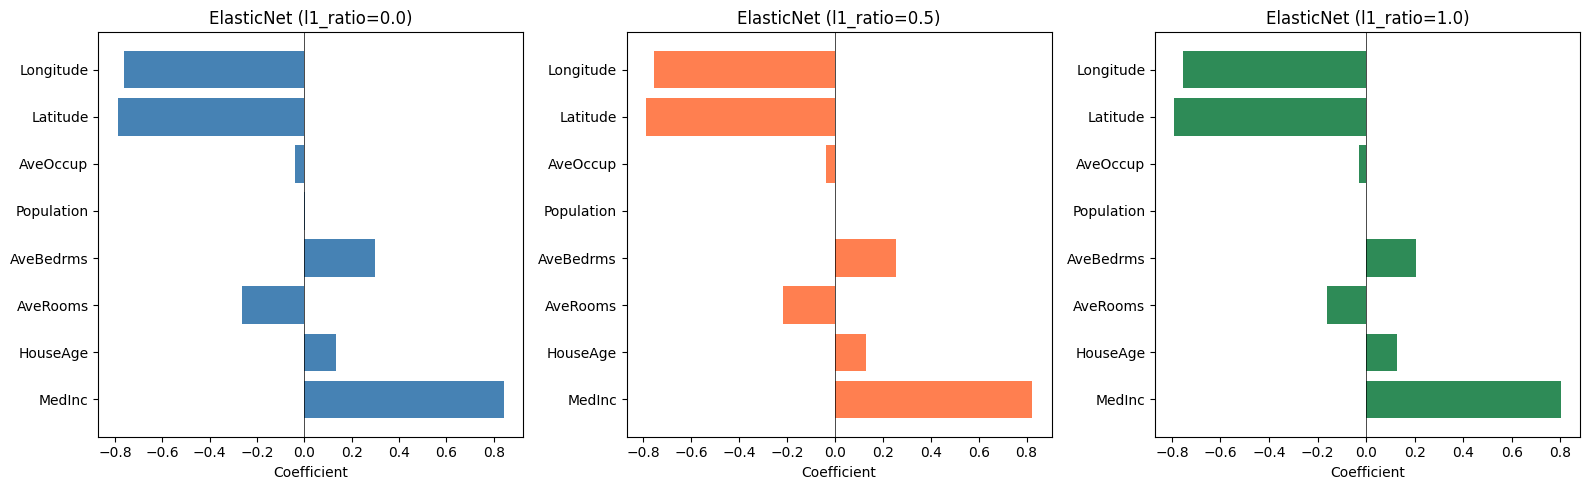


ElasticNet (l1_ratio=0.0) coefficients:
 MedInc      :   0.8436
 HouseAge    :   0.1333
 AveRooms    :  -0.2619
 AveBedrms   :   0.2997
 Population  :   0.0012
 AveOccup    :  -0.0413
 Latitude    :  -0.7888
 Longitude   :  -0.7601

ElasticNet (l1_ratio=0.5) coefficients:
 MedInc      :   0.8240
 HouseAge    :   0.1300
 AveRooms    :  -0.2161
 AveBedrms   :   0.2563
 Population  :  -0.0000 <-- REMOVED 
 AveOccup    :  -0.0359
 Latitude    :  -0.7884
 Longitude   :  -0.7570

ElasticNet (l1_ratio=1.0) coefficients:
 MedInc      :   0.8010
 HouseAge    :   0.1271
 AveRooms    :  -0.1628
 AveBedrms   :   0.2062
 Population  :  -0.0000 <-- REMOVED 
 AveOccup    :  -0.0306
 Latitude    :  -0.7901
 Longitude   :  -0.7557


In [23]:
# Train ElasticNet with different l1_ratio values
models_en = {}

ratios = [0.0, 0.5, 1.0]

for r in ratios:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=r, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    models_en[f'ElasticNet (l1_ratio={r})'] = pipe


# Plot coefficients (same format as yours)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [
    'ElasticNet (l1_ratio=0.0)',
    'ElasticNet (l1_ratio=0.5)',
    'ElasticNet (l1_ratio=1.0)'
]

colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models_en[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()


# Print coefficients for l1_ratio=1.0 (Lasso equivalent)
feature_names = housing.feature_names  # or your own feature list

for r in ratios:
    coefs = models_en[f'ElasticNet (l1_ratio={r})'].named_steps['model'].coef_

    print(f"\nElasticNet (l1_ratio={r}) coefficients:")
    for feat, coef in zip(feature_names, coefs):
        status = '' if abs(coef) > 0.001 else ' <-- REMOVED '
        print(f' {feat:12s}: {coef:>8.4f}{status}')

**At l1_ratio=0.0, what model does it become? At l1_ratio=1.0?**

*When l1_ratio = 0.0, ElasticNet becomes equivalent to Ridge regression, because only the L2 penalty is applied.*

*When l1_ratio = 1.0, ElasticNet becomes equivalent to Lasso regression, since only the L1 penalty is used.*

## 9 Part 8: The Alpha Tuning Experiment

Choosing the right α is critical. Let’s systematically search for the best value using a loop.

### 9.1 Step 1: Ridge Alpha Search

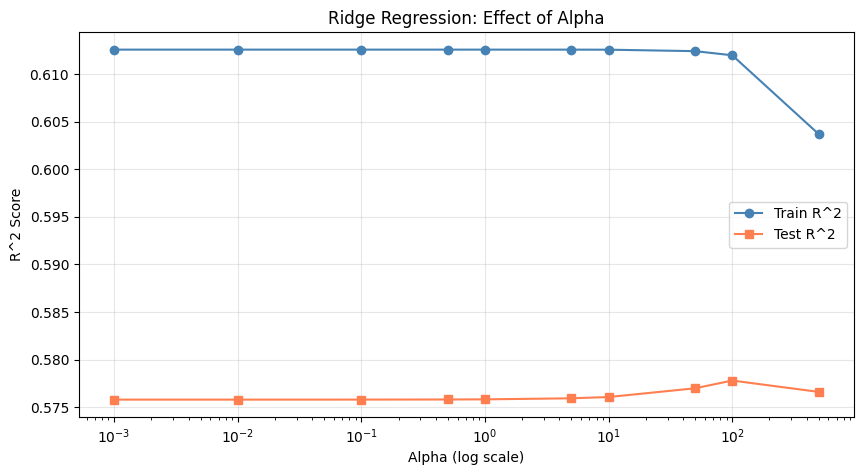

Best alpha: 100.0
Best test R^2: 0.5778


In [24]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0,
          50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(
        r2_score(y_train, pipe.predict(X_train))
    )

    test_scores.append(
        r2_score(y_test, pipe.predict(X_test))
    )

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-',
             label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-',
             label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha
best_idx = np.argmax(test_scores)
print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

### Task 7: Tune Lasso Alpha

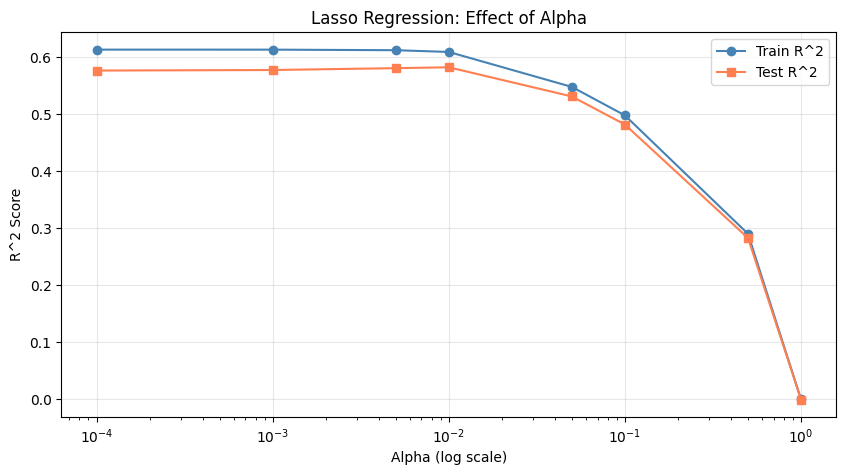

Best alpha: 0.01
Best test R^2: 0.5816


In [25]:
#repeat the alpha search experiment for Lasso
alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=50000))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(
        r2_score(y_train, pipe.predict(X_train))
    )

    test_scores.append(
        r2_score(y_test, pipe.predict(X_test))
    )


#plot train and test R^2 vs alpha, just like the Ridge plot above
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-',
             label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-',
             label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha
best_idx = np.argmax(test_scores)
print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

In [26]:
#count how many features Lasso keeps

alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

results = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=50000))
    ])

    pipe.fit(X_train, y_train)

    coefs = pipe.named_steps['lasso'].coef_

    num_kept = np.sum(np.abs(coefs) > 1e-6)
    test_r2 = r2_score(y_test, pipe.predict(X_test))

    results.append((alpha, num_kept, test_r2))

#print results
print("Alpha  Features Kept  Test R²")
for alpha, kept, r2_val in results:
    print(f"{alpha:<6} {kept:<14} {r2_val:.4f}")

Alpha  Features Kept  Test R²
0.0001 8              0.5759
0.001  8              0.5769
0.005  7              0.5801
0.01   7              0.5816
0.05   4              0.5305
0.1    3              0.4814
0.5    1              0.2827
1.0    0              -0.0002


**How many features Lasso keeps (coefficient ̸= 0)?**

- α = 0.0001 → 8 features

- α = 0.001 → 8 features

- α = 0.005 → 7 features

- α = 0.01 → 7 features

- α = 0.05 → 4 features

- α = 0.1 → 3 features

- α = 0.5 → 1 feature

- α = 1.0 → 0 features

**At what alpha does Lasso start removing features aggressively?**

*Small removal begins at 0.005 (8 → 7)*

*Aggressive removal starts at: α = 0.05*

*Because the model drops from 7 features to 4, and then continues shrinking quickly.*

**Which alpha gives the best test R² for Lasso?**

*The highest test R² is: α = 0.01 (Test R² = 0.5816)*

## 10 Part 9: Final Model Comparison

Let’s bring everything together and compare all the models we have built in this lab.

### 10.1 Step 1: Comprehensive Comparison

In [27]:
# Rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),
    'ElasticNet (a=0.01, l1=0.5)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

# Evaluate
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8}'
      f'{"R^2":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []
for name, pipe in all_models.items():
    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train[:, [0]] # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Count effective features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        'Model': name,'RMSE': rmse_v,
        'MAE': mae_v, 'R2': r2_v,'Features': n_feat})
    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f}'
          f'{r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE     R^2 # Features
Simple LR (MedInc)          0.8421   0.6299  0.4589          1
Multiple LR (all)           0.7456   0.5332  0.5758          8
Polynomial (deg=2)          0.6814   0.4670  0.6457         44
Ridge (alpha=1.0)           0.7456   0.5332  0.5758          8
Lasso (alpha=0.01)          0.7404   0.5353  0.5816          8
ElasticNet (a=0.01, l1=0.5)   0.7416   0.5341  0.5803          8


### 10.2 Step 2: Visual Comparison

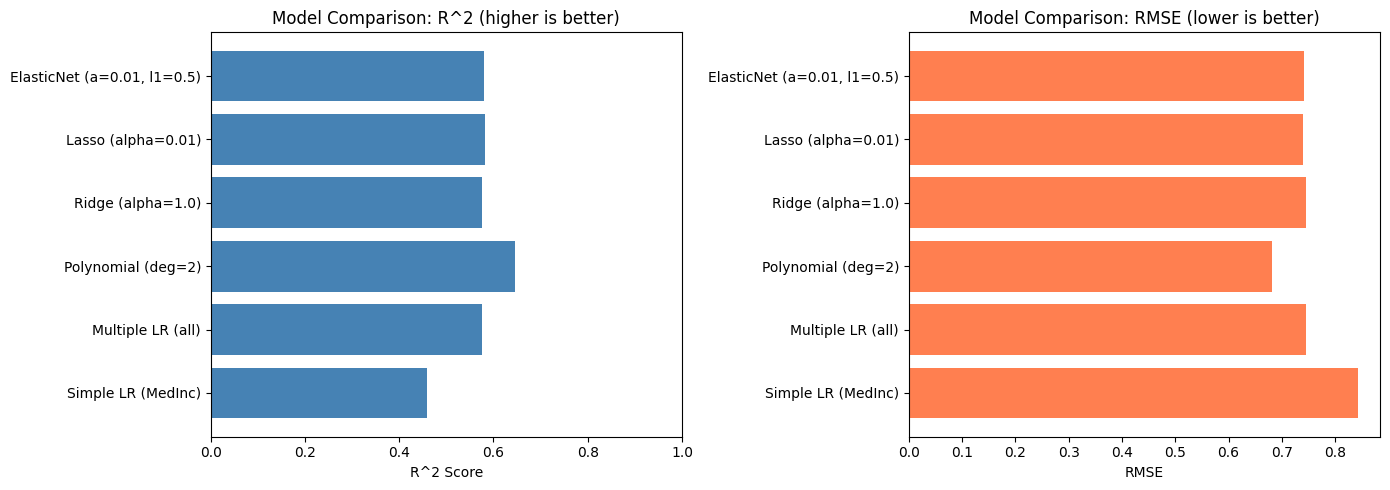

In [28]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

### Task 8: Draw Conclusions

**Which model achieved the best R² on the test set?**

*Polynomial Regression (degree 2) achieved the highest R².*

*It slightly outperforms the other models.*


**Which model had the lowest RMSE?**

*Polynomial Regression (degree 2) has the lowest RMSE.*

*Since RMSE measures prediction error (lower is better), this confirms it performs best among the compared models.*

**Is the improvement in R² worth the added complexity? Justify your answer.**

*The Polynomial model expands the feature space from 8 to 44 features. Although it slightly improves performance compared to basic Linear Regression, its performance is very similar to ElasticNet.*

- It is significantly more complex.

- It is harder to interpret.

- It increases the risk of overfitting.

- It requires more computation.

*Because ElasticNet achieves similar or better performance using only the original 8 features, the small improvement from Polynomial regression is not worth the added complexity.*

**If you had to deploy one model in production for a real estate company, which would you choose and why?**

*I would choose Multiple Linear Regression (with all features).*

*It performs nearly as well as Polynomial Regression but is:*

- Simpler

- More interpretable

- Easier to maintain

- Less prone to overfitting

*In production systems, simplicity and stability are usually preferred when performance differences are small.*

**Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?**

*They perform similarly because:*

- The dataset is largely linear.

- There is no severe multicollinearity.

- The optimal regularization strength is relatively small.

- Linear Regression already captures most of the underlying signal.

*Regularization mainly shrinks coefficients slightly rather than drastically changing the model, so performance remains close to standard Linear Regression.*

## 11 Part 10: Apply to a New Dataset – Saudi Housing

To solidify your skills, let’s apply the complete regression workflow to a different dataset. We
will create a synthetic Saudi housing dataset and you will run the full analysis.

### 11.1 Step 1: Create the Saudi Housing Dataset

In [29]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n,
    p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

# Base price varies by city (in SAR thousands)
city_base = {
    'Jeddah': 850,
    'Riyadh': 900,
    'Dammam': 650,
    'Makkah': 1100,
    'Madinah': 750
}

base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

# Generate price with realistic relationships
price = (
    base
    + 3.5 * area
    + 80 * bedrooms
    + 50 * bathrooms
    - 12 * age
    + 15 * floor
    + 100 * has_parking
    + np.random.normal(0, 150, n)   # noise
)

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price   # price in thousands of SAR
})

df_saudi.to_csv('saudi_housing.csv', index=False)

print(f"Dataset shape: {df_saudi.shape}")
print(df_saudi.head(10))
print("\nPrice statistics (thousands SAR):")
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

## Task 9: Full Saudi Housing Analysis (Challenge)

###1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the data.

Dataset Overview:
Shape (rows, columns): (500, 8)


Descriptive Statistics:


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
count,500.00,500.00,500.00,500.0,500.00,500.00,500.00
mean,234.22,3.50,2.45,19.6,7.52,0.71,2044.35
std,91.36,1.71,1.13,11.6,3.97,0.46,452.24
min,81.50,1.00,1.00,0.0,1.00,0.00,833.80
25%,153.35,2.00,1.00,10.0,4.00,0.00,1737.22
50%,231.00,3.00,2.00,20.0,8.00,1.00,2038.55
75%,312.40,5.00,3.00,30.0,11.00,1.00,2344.07
max,399.90,6.00,4.00,39.0,14.00,1.00,3326.90




Correlation Matrix (Numeric Features):


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
area_sqm,1.000,-0.029,0.002,-0.078,-0.114,-0.051,0.730
bedrooms,-0.029,1.000,0.010,0.005,-0.033,0.042,0.300
bathrooms,0.002,0.010,1.000,0.061,0.018,0.029,0.091
age_years,-0.078,0.005,0.061,1.000,-0.050,0.097,-0.366
floor,-0.114,-0.033,0.018,-0.050,1.000,0.006,0.071
has_parking,-0.051,0.042,0.029,0.097,0.006,1.000,0.023
price_kSAR,0.730,0.300,0.091,-0.366,0.071,0.023,1.000




Scatter Plots:


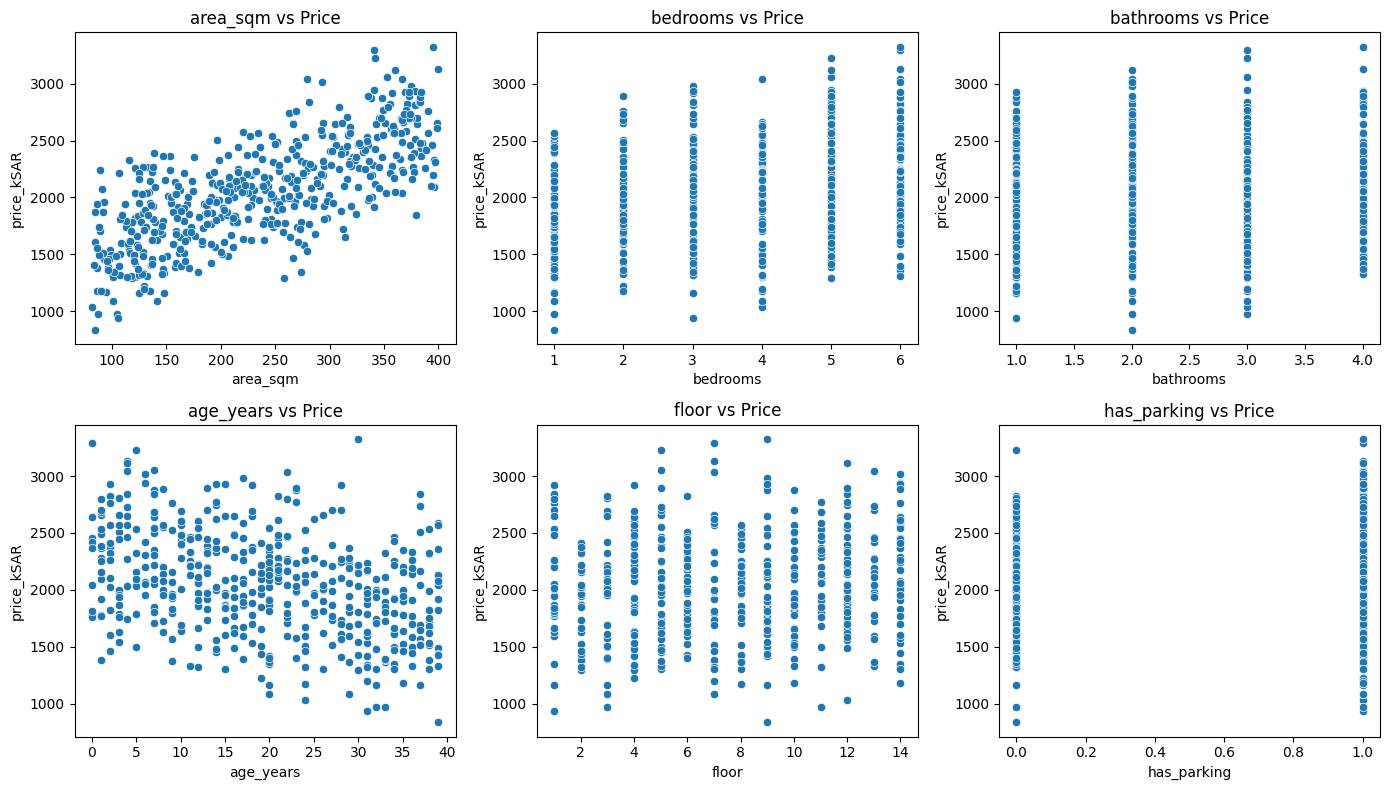

In [30]:
#Explore: Use df.describe(), df.corr(), and scatter plots to understand the data.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

df = pd.read_csv("saudi_housing.csv")

print("Dataset Overview:")
print(f"Shape (rows, columns): {df.shape}")

print("\n")
print("Descriptive Statistics:")
display(df.describe().round(2))

print("\n")
print("Correlation Matrix (Numeric Features):")
display(df.corr(numeric_only=True).round(3))

features = ['area_sqm', 'bedrooms', 'bathrooms',
            'age_years', 'floor', 'has_parking']

print("\n")
print("Scatter Plots:")
plt.figure(figsize=(14,8))
for i, feat in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.scatterplot(x=df[feat], y=df['price_kSAR'])
    plt.title(f"{feat} vs Price")
plt.tight_layout()
plt.show()

*These scatter plots show how each feature relates to house price:*

- area_sqm: Strong positive trend — larger houses tend to be more expensive.

- bedrooms & bathrooms: Slight positive relationship — more rooms generally increase price, but not as strongly as area.

- age_years: Negative trend — older houses tend to have lower prices.

- floor: Very weak relationship — no clear strong pattern.

- has_parking: Houses with parking (1) appear slightly more expensive than those without (0).

*Overall, area_sqm is the strongest visible predictor of price.*

In [31]:
#find Most Correlated Feature with price
print("\nCorrelation with price:")
df.corr(numeric_only=True)['price_kSAR'].sort_values(ascending=False)


Correlation with price:


,price_kSAR
price_kSAR,1.000000
area_sqm,0.730056
bedrooms,0.300025
bathrooms,0.090535
floor,0.071430
has_parking,0.023281
age_years,-0.366188


**Which feature correlates most with price?**

*The feature that correlates most with price is area_sqm, with a strong positive correlation of approximately 0.73, indicating that larger properties tend to have significantly higher prices.*

###2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale the numeric features.

In [32]:
#Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale the numeric features.

#separate features and target
X = df.drop(columns=['price_kSAR'])
y = df['price_kSAR']

#One-hot encode categorical column
X_encoded = pd.get_dummies(X, columns=['city'], drop_first=True)

print("Encoded Features (first 5 rows):")
print(X_encoded.head())

#scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("\nAfter Scaling:")
print("Shape of scaled data:", X_scaled.shape)
print("Number of features:", X_scaled.shape[1])

Encoded Features (first 5 rows):
   area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  city_Jeddah  \
0     303.4         4          4         24     11            0        False   
1     251.6         6          4          1      1            1        False   
2     179.0         3          1         34     14            0        False   
3     340.4         5          3          6     14            1        False   
4     299.1         1          3         20      6            0         True   

   city_Madinah  city_Makkah  city_Riyadh  
0         False        False         True  
1          True        False        False  
2         False        False        False  
3         False        False         True  
4         False        False        False  

After Scaling:
Shape of scaled data: (500, 10)
Number of features: 10


###3. Simple model: Train a Linear Regression using only area sqm. Plot the regression line and report R^2

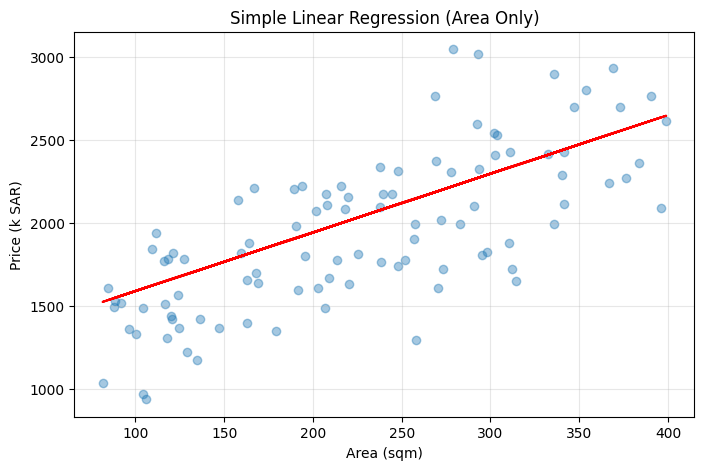


Simple Model R²: 0.4932


In [33]:
#Simple model: Train a Linear Regression using only area sqm. Plot the regression line and report R^2
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

X_area = df[['area_sqm']].to_numpy()
y_saudi = df['price_kSAR'].to_numpy()

X_train_area, X_test_area, y_train_area, y_test_area = train_test_split(
    X_area, y_saudi, test_size=0.2, random_state=42
)

simple_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

simple_pipe.fit(X_train_area, y_train_area)
y_pred_simple = simple_pipe.predict(X_test_area)

r2_simple = r2_score(y_test_area, y_pred_simple)

plt.figure(figsize=(8,5))
plt.scatter(X_test_area, y_test_area, alpha=0.4)
plt.plot(X_test_area, y_pred_simple, color='red')
plt.xlabel("Area (sqm)")
plt.ylabel("Price (k SAR)")
plt.title("Simple Linear Regression (Area Only)")
plt.grid(True, alpha=0.3)
plt.show()

print("\nSimple Model R²:", round(r2_simple, 4))

**Plot the regression line and report R².**

*The regression line shows a clear positive linear relationship between area (sqm) and price.*

*The model achieved: R² = 0.4932*

*This means that approximately 49.3% of the variance in housing price is explained by area alone.*

*While area is an important predictor, it does not fully explain price variation, indicating that other features (such as city, bedrooms, and age) also significantly influence housing prices.*

###4. Multiple model: Train with all features.

In [34]:
#Multiple model: Train with all features.
y_saudi = df['price_kSAR'].to_numpy()

X_train_enc, X_test_enc, y_train_saudi, y_test_saudi = train_test_split(
    X_encoded, y_saudi, test_size=0.2, random_state=42
)

pipe_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_multi.fit(X_train_enc, y_train_saudi)

y_pred_multi = pipe_multi.predict(X_test_enc)
r2_multi = r2_score(y_test_saudi, y_pred_multi)

print("Multiple Model R²:", round(r2_multi, 4))
print("Improvement:", round(r2_multi - r2_simple, 4))

Multiple Model R²: 0.8645
Improvement: 0.3714


**How much does R² improve?**

*When training with all features, the R² increases from 0.4932 to 0.8645, resulting in an improvement of 0.3714.*

*This means that adding the remaining features (city, bedrooms, bathrooms, age, floor, parking) significantly improves the model’s explanatory power, increasing the variance explained from about 49% to 86%.*

In [35]:
#Regularized models: Train Ridge, Lasso, and ElasticNet.
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=50000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=50000)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train_enc, y_train_saudi)
    y_pred = pipe.predict(X_test_enc)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test_saudi, y_pred)),
        "MAE": mean_absolute_error(y_test_saudi, y_pred),
        "R^2": r2_score(y_test_saudi, y_pred)
    }

pd.DataFrame(results).T

,RMSE,MAE,R^2
Ridge,173.223331,137.468836,0.864213
Lasso,173.033347,137.306708,0.864511
ElasticNet,173.444322,137.736900,0.863867


**Compare their performance.**

*Ridge, Lasso, and ElasticNet show nearly identical performance. Lasso performs slightly better, achieving the highest R² (0.8645) and the lowest RMSE and MAE.*

*However, the differences are minimal, indicating that the dataset is largely linear and does not require strong regularization.*

###6. Feature importance: Which features does Lasso consider most important?

In [36]:
#Feature importance: Which features does Lasso consider most important?
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import pandas as pd

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.01, max_iter=50000))
])

lasso_pipe.fit(X_train_enc, y_train_saudi)

coef_df = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Coefficient": lasso_pipe.named_steps['model'].coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
0,area_sqm,333.997272
8,city_Makkah,193.199506
1,bedrooms,142.300663
3,age_years,-128.050746
9,city_Riyadh,124.382949
6,city_Jeddah,104.627189
4,floor,74.014130
2,bathrooms,53.945781
5,has_parking,42.222997
7,city_Madinah,39.817615


**Which features does Lasso consider most important? Does this match your intuition about Saudi housing prices?**

*Lasso identifies **area_sqm** as the most important feature affecting house prices. Location variables such as **city_Makkah** and **city_Riyadh** also have strong influence, while property characteristics like **bedrooms** and **age_years** contribute to price variation. The negative coefficient for **age_years** suggests that older properties tend to have lower prices.*

*These results align well with real-world expectations in the Saudi housing market. Property size and location are major factors that influence housing prices, and larger homes in major cities tend to be more valuable. Additionally, newer properties generally maintain higher market value compared to older ones. Overall, the model’s feature importance reflects realistic economic drivers of real estate pricing.*

In [37]:
#Comparison table: Create a summary table comparing all models (RMSE, MAE, R²)
comparison = {
    "Simple LR (Area)": {
        "RMSE": np.sqrt(mean_squared_error(y_test_saudi, y_pred_simple)),
        "MAE": mean_absolute_error(y_test_saudi, y_pred_simple),
        "R^2": r2_simple
    },
    "Multiple LR (All)": {
        "RMSE": np.sqrt(mean_squared_error(y_test_saudi, y_pred_multi)),
        "MAE": mean_absolute_error(y_test_saudi, y_pred_multi),
        "R^2": r2_multi
    }
}

comparison.update(results)

comp_df = pd.DataFrame(comparison).T
comp_df

,RMSE,MAE,R^2
Simple LR (Area),334.666127,276.058355,0.493164
Multiple LR (All),173.029522,137.301214,0.864517
Ridge,173.223331,137.468836,0.864213
Lasso,173.033347,137.306708,0.864511
ElasticNet,173.444322,137.736900,0.863867


**Identify the best model.**

*The best-performing model is Multiple Linear Regression, as it achieves the highest R² (0.8645) and the lowest RMSE and MAE.*

*While Ridge, Lasso, and ElasticNet perform very similarly, Multiple Linear Regression provides slightly better overall accuracy on this dataset.*

## 12 Part 11: Summary and Key Takeaways

### 12.1 Models Covered in This Lab

**Model:** Linear Regression

**Key Idea:** Minimize squared errors

**Strengths:** Simple, interpretable

**When to Use:** Linear relationships


---

**Model:** Polynomial

**Key Idea:** Add power terms  

**Strengths:** Captures curves

**When to Use:** Non-linear data


---

**Model:** Ridge (L2)

**Key Idea:** Penalize large weights  

**Strengths:** Stable predictions

**When to Use:** Many features


---

**Model:** Lasso (L1)

**Key Idea:** Force weights to zero  

**Strengths:** Feature selection

**When to Use:** Sparse models


---

**Model:** ElasticNet

**Key Idea:** L1 + L2  

**Strengths:** Best of both

**When to Use:** Correlated feature

### 12.2 Key Rules to Remember

1. Always visualize your data before modeling – scatter plots reveal relationships and outliers.

2. Start simple: Try Linear Regression first, then add complexity only if needed.

3. Evaluate properly: Use R2 to measure how much variance is explained and RMSE for error in original units.

4. Regularize when needed: Ridge and Lasso prevent overfitting, especially with many features or polynomial expansion.

5. Use Lasso for feature selection: When you need to know which features matter most.

6. Check residuals: Random residuals = good model; patterns in residuals = model is missing something.

### 12.3 What is Coming Next

In Lab 5, you will implement Linear Regression from scratch using gradient descent. You will code the cost function, compute gradients manually, and watch the model learn step by
step. This will give you deep understanding of what scikit-learn does behind the scenes!

## 13 Submission Requirements

### 13.1 What to Submit

**Which model performed best?**

*The multiple linear regression model performed best, achieving an R² of approximately 0.86, compared to about 0.49 for the simple linear regression model using only area. This shows that including all features significantly improves prediction accuracy because housing prices depend on multiple factors.*

**What role did regularization play?**

*Regularized models (Ridge, Lasso, and ElasticNet) performed very similarly to standard multiple regression, indicating that overfitting was not severe in this dataset. However, Lasso was particularly useful because it shrinks less important coefficients and helps identify the most relevant predictors.*

**Which features were most predictive of house prices?**

*The most predictive features were area, city location (especially Makkah and Riyadh), number of bedrooms, and property age (which had a negative effect). These results align well with real-world expectations of the Saudi housing market, where larger homes in major cities and newer properties tend to have higher prices.*